# ❤️ Heart Explainable AI

This notebook demonstrates Explainable Artificial Intelligence (XAI) for heart disease prediction using a Random Forest machine learning model, a PyTorch deep learning model, and SHAP explanations.

## Import pickle

`pickle` is used to load the saved machine learning and deep learning models from `.pkl` files.

In [19]:
import pickle

## Optional: Hide scikit-learn version warnings

This hides warnings that may appear when a model was saved using a different scikit-learn version.

In [20]:
import warnings
from sklearn.exceptions import InconsistentVersionWarning

warnings.filterwarnings("ignore", category=InconsistentVersionWarning)

## Load the machine learning model

The Random Forest model is loaded from `ml_model.pkl`.

In [21]:
ml_model_file = open("ml_model.pkl", "rb")
ml_model = pickle.load(ml_model_file)
ml_model_file.close()

## Import pandas

`pandas` is used to read and process the heart disease dataset.

In [22]:
import pandas as pd

## Load the dataset

The dataset is loaded from `heart_dataset.csv`.

In [23]:
df = pd.read_csv("heart_dataset.csv")

## Select feature columns

The feature columns are selected up to `thallium_heart_rate`.

In [24]:
dataset_features = df.loc[:, :"thallium_heart_rate"]
feature_names = dataset_features.columns.to_list()

## Extract decision trees from the Random Forest

A Random Forest is made up of many decision trees. This extracts all trees from the model.

In [25]:
decision_trees = ml_model.estimators_
print(len(decision_trees))

100


## Select one decision tree

The first decision tree is selected for visualization.

In [26]:
decision_tree = decision_trees[0]

## Import decision tree plotting function

`plot_tree` is used to visualize the selected decision tree.

In [27]:
from sklearn.tree import plot_tree

## Plot the full decision tree

This displays the full selected decision tree.

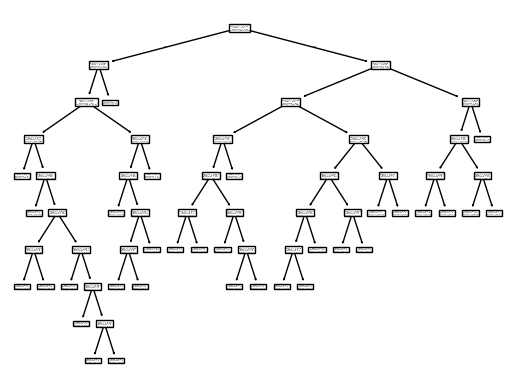

In [28]:
_ = plot_tree(decision_tree)

## Plot a simplified decision tree

This displays only the first two levels of the tree, making it easier to read.

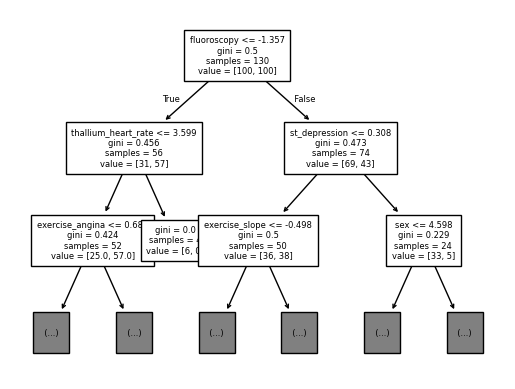

In [29]:
_ = plot_tree(
    decision_tree,
    max_depth=2,
    feature_names=feature_names,
    fontsize=6
)

## Load the deep learning model

The PyTorch deep learning model is loaded from `dl_model.pkl`.

In [30]:
import torch.nn as nn

class HeartDLModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(13, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x)

dl_model_file = open("dl_model.pkl", "rb")
dl_model = pickle.load(dl_model_file)
dl_model_file.close()

## Convert dataset features to NumPy

SHAP works better with NumPy arrays, so the dataset features are converted.

In [31]:
dataset_features = dataset_features.to_numpy()

## Select one sample

The first patient record is selected for individual SHAP explanation.

In [32]:
one_sample_features = dataset_features[0]

## Import PyTorch

PyTorch is used so the deep learning model can use tensors and run predictions.

In [33]:
import torch

## Wrap the deep learning model

This wrapper allows SHAP to send NumPy data into the PyTorch model and receive NumPy predictions.

In [34]:
dl_model_wrapped = lambda features: dl_model(
    torch.Tensor(features)
).detach().numpy()

## Import SHAP and tqdm

SHAP is used for explainability. `tqdm.auto` is used for progress display.

In [35]:
import tqdm.auto
import shap

## Create the SHAP explainer

The first 100 rows are used as background data for the SHAP KernelExplainer.

In [36]:
shap_explainer = shap.KernelExplainer(
    dl_model_wrapped,
    dataset_features[:100]
)

## Get the SHAP expected value

The expected value is the model's base prediction before feature contributions are added.

In [37]:
shap_expected_value = shap_explainer.expected_value

## Calculate SHAP values for one sample

This calculates how each feature contributes to the prediction for one patient record.

In [38]:
one_sample_shap_values = shap_explainer.shap_values(one_sample_features)
print(one_sample_shap_values)

[[ 0.00210907]
 [-0.00125549]
 [-0.01283184]
 [ 0.        ]
 [ 0.        ]
 [ 0.        ]
 [-0.00075905]
 [ 0.        ]
 [ 0.00113196]
 [-0.00144769]
 [-0.00170158]
 [ 0.00218692]
 [-0.00040021]]


## Import Matplotlib

Matplotlib is used to display plots.

In [39]:
import matplotlib.pyplot as plt

## Create a SHAP force plot

The SHAP values are flattened so their length matches the number of input features.

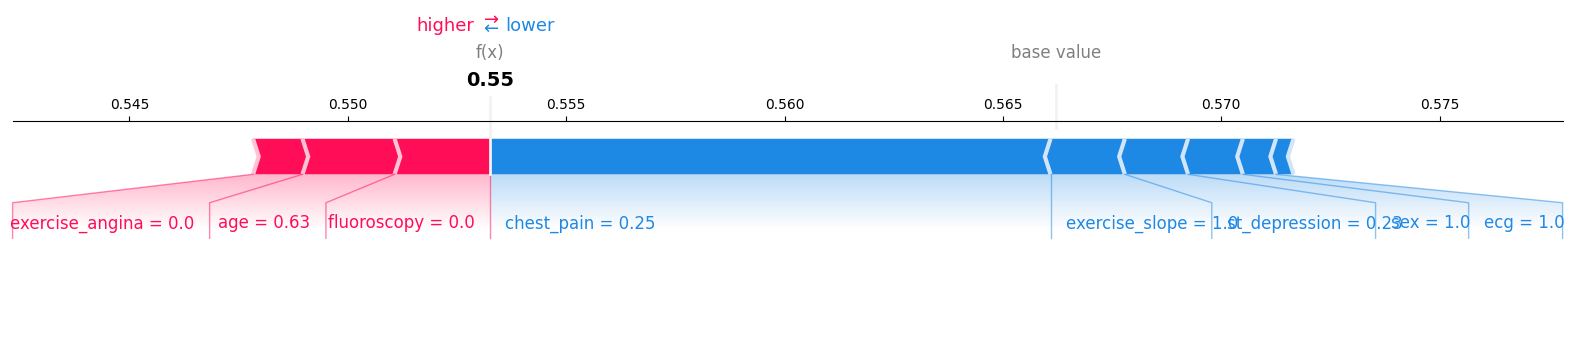

In [40]:
single_shap_values = one_sample_shap_values.flatten()

shap.force_plot(
    shap_expected_value[0],
    single_shap_values,
    one_sample_features,
    feature_names=feature_names,
    matplotlib=True,
    show=True
)

## Select multiple samples

The first 10 patient records are selected for global SHAP explanation.

In [41]:
multiple_samples_features = dataset_features[:10]

## Calculate SHAP values for multiple samples

This calculates feature contributions for the selected patient records.

In [42]:
multiple_samples_shap_values = shap_explainer.shap_values(
    multiple_samples_features
)

  0%|          | 0/10 [00:00<?, ?it/s]

## Create a SHAP summary plot

The summary plot shows which features are most important across multiple predictions.

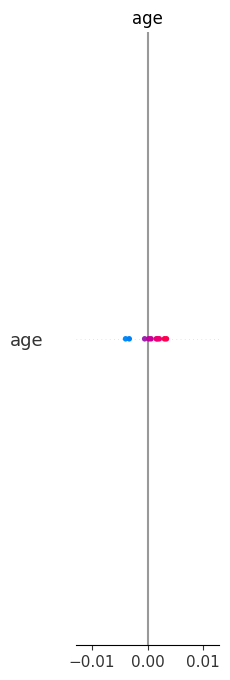

In [43]:
shap.summary_plot(
    multiple_samples_shap_values,
    multiple_samples_features,
    feature_names=feature_names
)